In [23]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## Step 1 - Load the Dataset

In [24]:
# Load dataset
df = pd.read_csv('../data/weddify_dataset_v_final.csv')

print('Dataset loaded!')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Dataset loaded!
Shape: (13304, 14)

Columns: ['vendor_name', 'Category', 'Location', 'Price Tier', 'Price (LKR)', 'Rating (out of 5)', 'Experience (Years)', 'Weddings Completed', 'Response Time (Hours)', 'Verified', 'Number of Packages', 'Social Media Followers', 'Repeat Client Rate', 'Recommended']


,vendor_name,Category,Location,Price Tier,Price (LKR),Rating (out of 5),Experience (Years),Weddings Completed,Response Time (Hours),Verified,Number of Packages,Social Media Followers,Repeat Client Rate,Recommended
0,Artisan Cards Lanka,Wedding Invitations,Colombo,Mid-Range,36000,3.8,8,120,3.0,Yes,2,37492,0.35,Yes
1,Suwandha Catering,Catering,Colombo,Premium,1051800,5.0,13,182,5.4,Yes,6,100000,0.60,Yes
2,Sithara Bridal Studio,Attire & Beauty,Colombo,Mid-Range,92500,4.0,12,300,13.1,No,3,12616,0.44,Yes
3,Luxury Rides Lanka,Wedding Cars,Colombo,Mid-Range,59300,4.7,17,221,1.8,Yes,2,28867,0.45,Yes
4,Paper & Petals Lanka,Wedding Invitations,Kurunegala,Mid-Range,33300,3.8,7,63,11.2,No,4,18873,0.32,No


## Step 2 - Separate Features and Target
X = all columns except Recommended (input features)

y = Recommended column (what we want to predict)

In [25]:
# X = features (everything except target)
X = df.drop(columns=['Recommended'])

# y = target (what we predict)
y = df['Recommended']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nTarget values:', y.unique())
print('\nTarget distribution:')
print(y.value_counts())

X shape: (13304, 13)
y shape: (13304,)

Target values: ['Yes' 'No']

Target distribution:
Recommended
No     6672
Yes    6632
Name: count, dtype: int64


## Step 3 - Identify Column Types
We need to know which columns are text (categorical) and which are numbers (numerical)

In [26]:
# Categorical columns (text)
cat_cols = ['Category', 'Location', 'Price Tier', 'Verified']

# Numerical columns (numbers)
num_cols = ['Price (LKR)', 'Rating (out of 5)', 'Experience (Years)',
            'Weddings Completed', 'Response Time (Hours)',
            'Number of Packages', 'Social Media Followers',
            'Repeat Client Rate']

print('Categorical columns:', cat_cols)
print('Numerical columns  :', num_cols)

Categorical columns: ['Category', 'Location', 'Price Tier', 'Verified']
Numerical columns  : ['Price (LKR)', 'Rating (out of 5)', 'Experience (Years)', 'Weddings Completed', 'Response Time (Hours)', 'Number of Packages', 'Social Media Followers', 'Repeat Client Rate']


## Step 4 - Encode Categorical Columns
ML models only understand numbers.

We convert text like "Colombo", "Budget", "Yes" into numbers.

In [27]:
# Create a copy so we don't change original data
X_encoded = X.copy()

# Store encoders so we can use them later in the API
encoders = {}

# Encode each categorical column
for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    encoders[col] = le
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print('\nEncoding done!')

Encoded 'Category': {'Attire & Beauty': 0, 'Catering': 1, 'Decorators': 2, 'Entertainment': 3, 'Photographers': 4, 'Venues': 5, 'Wedding Cakes': 6, 'Wedding Cars': 7, 'Wedding Invitations': 8}
Encoded 'Location': {'Ampara': 0, 'Anuradhapura': 1, 'Badulla': 2, 'Batticaloa': 3, 'Colombo': 4, 'Galle': 5, 'Gampaha': 6, 'Hambantota': 7, 'Jaffna': 8, 'Kalutara': 9, 'Kandy': 10, 'Kegalle': 11, 'Kurunegala': 12, 'Mannar': 13, 'Matale': 14, 'Matara': 15, 'Monaragala': 16, 'Mullaitivu': 17, 'Negombo': 18, 'Nuwara Eliya': 19, 'Polonnaruwa': 20, 'Puttalam': 21, 'Ratnapura': 22, 'Trincomalee': 23, 'Vavuniya': 24}
Encoded 'Price Tier': {'Budget': 0, 'Mid-Range': 1, 'Premium': 2}
Encoded 'Verified': {'No': 0, 'Yes': 1}

Encoding done!


In [28]:
# Encode target column (Yes=1, No=0)
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print('Target encoding:', dict(zip(target_encoder.classes_,
                                    target_encoder.transform(target_encoder.classes_))))
print('Sample:', y_encoded[:10])

Target encoding: {'No': 0, 'Yes': 1}
Sample: [1 1 1 1 0 0 1 1 0 1]


## Step 5 - Scale Numerical Columns
Large numbers like Price (LKR) can confuse ML models.

We scale all numbers to a similar range using StandardScaler.

In [29]:
# Scale numerical columns
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print('Scaling done!')
print('\nAfter scaling - stats for Price (LKR):')
print(f'  Mean : {X_encoded["Price (LKR)"].mean():.4f}  (should be ~0)')
print(f'  Std  : {X_encoded["Price (LKR)"].std():.4f}   (should be ~1)')
X_encoded.head()

Scaling done!

After scaling - stats for Price (LKR):
  Mean : -0.0000  (should be ~0)
  Std  : 1.0000   (should be ~1)


,vendor_name,Category,Location,Price Tier,Price (LKR),Rating (out of 5),Experience (Years),Weddings Completed,Response Time (Hours),Verified,Number of Packages,Social Media Followers,Repeat Client Rate
0,Artisan Cards Lanka,8,4,1,-0.531493,0.102449,-0.157713,-0.226896,-1.192358,1,-0.755161,0.824548,0.276313
1,Suwandha Catering,1,4,2,3.572261,2.069225,0.820201,0.457660,-0.921441,1,2.106320,3.636895,2.365894
2,Sithara Bridal Studio,0,4,1,-0.303238,0.430245,0.624618,1.760524,-0.052252,0,-0.039791,-0.294668,1.028562
3,Luxury Rides Lanka,7,4,1,-0.437363,1.577531,1.602532,0.888267,-1.327816,1,-0.755161,0.436494,1.112145
4,Paper & Petals Lanka,8,12,1,-0.542401,0.102449,-0.353296,-0.856246,-0.266727,0,0.675580,-0.013154,0.025564


## Step 6 - Split Data into Train and Test
80% of data for training the model

20% of data for testing the model

In [30]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print('Train set size :', X_train.shape)
print('Test set size  :', X_test.shape)

print('\nTrain target distribution:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(target_encoder.classes_, counts):
    print(f'  {u}: {c} ({c/len(y_train)*100:.1f}%)')

print('\nTest target distribution:')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(target_encoder.classes_, counts):
    print(f'  {u}: {c} ({c/len(y_test)*100:.1f}%)')

Train set size : (10643, 13)
Test set size  : (2661, 13)

Train target distribution:
  No: 5337 (50.1%)
  Yes: 5306 (49.9%)

Test target distribution:
  No: 1335 (50.2%)
  Yes: 1326 (49.8%)


## Step 7 - Visualize Train/Test Split

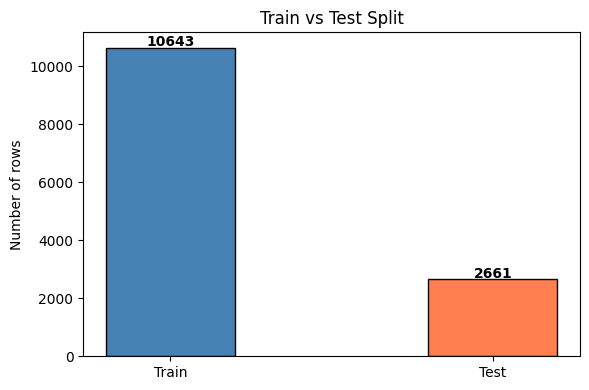

Total rows : 13304
Train rows : 10643 (80%)
Test rows  : 2661 (20%)


In [31]:
# Show the split visually
labels = ['Train', 'Test']
sizes  = [len(X_train), len(X_test)]
colors = ['steelblue', 'coral']

plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color=colors, width=0.4, edgecolor='black')
plt.title('Train vs Test Split')
plt.ylabel('Number of rows')
for i, v in enumerate(sizes):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/train_test_split.png')
plt.show()

print(f'Total rows : {len(X_train) + len(X_test)}')
print(f'Train rows : {len(X_train)} (80%)')
print(f'Test rows  : {len(X_test)} (20%)')

## Step 8 - Save Everything
Save the processed data and encoders so other notebooks can use them.

We never need to redo this step again.

In [32]:
# Create processed folder if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

# Save train and test data
joblib.dump(X_train, '../data/processed/X_train.pkl')
joblib.dump(X_test,  '../data/processed/X_test.pkl')
joblib.dump(y_train, '../data/processed/y_train.pkl')
joblib.dump(y_test,  '../data/processed/y_test.pkl')

# Save encoders and scaler
joblib.dump(encoders,       '../models/encoders.pkl')
joblib.dump(target_encoder, '../models/target_encoder.pkl')
joblib.dump(scaler,         '../models/scaler.pkl')

# Save column names for later use
joblib.dump(cat_cols, '../models/cat_cols.pkl')
joblib.dump(num_cols, '../models/num_cols.pkl')

print('Saved X_train, X_test, y_train, y_test  -> data/processed/')
print('Saved encoders, target_encoder, scaler  -> models/')
print('Saved cat_cols, num_cols                -> models/')

Saved X_train, X_test, y_train, y_test  -> data/processed/
Saved encoders, target_encoder, scaler  -> models/
Saved cat_cols, num_cols                -> models/

Saved encoders, target_encoder, scaler  -> models/
Saved cat_cols, num_cols                -> models/


## Step 9 - Verify Everything Saved Correctly

In [33]:
# Load back and check
X_train_check = joblib.load('../data/processed/X_train.pkl')
X_test_check  = joblib.load('../data/processed/X_test.pkl')
y_train_check = joblib.load('../data/processed/y_train.pkl')
y_test_check  = joblib.load('../data/processed/y_test.pkl')

print('Verification:')
print(f'  X_train : {X_train_check.shape} OK')
print(f'  X_test  : {X_test_check.shape} OK')
print(f'  y_train : {y_train_check.shape} OK')
print(f'  y_test  : {y_test_check.shape} OK')
print('\nAll files saved and verified successfully!')

Verification:
  X_train : (10643, 13) OK
  X_test  : (2661, 13) OK
  y_train : (10643,) OK
  y_test  : (2661,) OK

All files saved and verified successfully!
